# GAME AI – UNO using Adversarial Search

## 1. Imports

In [1]:
import random
import copy
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

## 2. Card & Deck Classes

In [2]:
COLORS = ['Red', 'Blue', 'Green', 'Yellow']
NUMBERS = list(range(10))

# Represents a singe UNO card
class Card:
    def __init__(self, color, value):
        self.color = color
        self.value = value

    @property
    def is_skip(self):
        return self.value == 'Skip'

    def matches(self, top_card):
        return (self.color == top_card.color) or (self.value == top_card.value)

    def __repr__(self):
        return f"{self.color} {self.value}"

    def __eq__(self, other):
        return isinstance(other, Card) and self.color == other.color and self.value == other.value

    def __hash__(self):
        return hash((self.color, self.value))

# Generate and shuffle a UNO deck
def build_deck():
    deck = []
    for color in COLORS:
        for number in NUMBERS:
            deck.append(Card(color, number))
        deck.append(Card(color, 'Skip'))
    random.shuffle(deck)
    return deck


test_deck = build_deck()
print(f"Test deck size: {len(test_deck)} cards")
print(f"Test sample cards: {test_deck[:5]}")

Test deck size: 44 cards
Test sample cards: [Blue 7, Blue 2, Green 0, Red 5, Yellow 4]


## 3. Game State

In [3]:
class GameState:
    def __init__(self, hands, top_card, deck, current=0, skip_next=False):
        self.hands = hands
        self.top_card = top_card
        self.deck = deck
        self.current = current
        self.skip_next = skip_next

    def clone(self):
        return GameState(
            hands=[list(h) for h in self.hands],
            top_card=self.top_card,
            deck=list(self.deck),
            current=self.current,
            skip_next=self.skip_next
        )

    @property
    # Return winner player's index else None
    def winner(self):
        for i, hand in enumerate(self.hands):
            if len(hand) == 0:
                return i
        return None

    def is_terminal(self):
        return self.winner is not None

    def __repr__(self):
        lines = [f"Top card : {self.top_card}",
                 f"Turn     : Player {self.current + 1}"]
        for i, h in enumerate(self.hands):
            lines.append(f"-> P{i+1} hand ({len(h)}): {h}")
        return '\n'.join(lines)


# Deal 5 cards to each player and flip the top card
def initialise_game():
    deck = build_deck()
    hands = [[], [], []]
    for _ in range(5):
        for p in range(3):
            hands[p].append(deck.pop())

    top = deck.pop()
    while top.is_skip:
        deck.insert(0, top)
        top = deck.pop()
    return GameState(hands=hands, top_card=top, deck=deck, current=0)


state = initialise_game()
print(state)

Top card : Blue 1
Turn     : Player 1
-> P1 hand (5): [Red Skip, Yellow 8, Blue Skip, Green 0, Blue 4]
-> P2 hand (5): [Red 0, Red 5, Yellow 6, Green 2, Yellow 2]
-> P3 hand (5): [Blue 7, Red 4, Green 9, Blue 2, Yellow 7]


## 4. Legal Move & State Transition

In [4]:
DRAW_ACTION = 'DRAW'


def get_valid_moves(hand, top_card):
    playable = [card for card in hand if card.matches(top_card)]
    if playable:
        return playable
    return [DRAW_ACTION]


def next_player(current, skip=False):
    steps = 2 if skip else 1
    return (current + steps) % 3


def apply_move(state: GameState, move) -> GameState:
    s = state.clone()
    player = s.current

    if move == DRAW_ACTION:
        # Draw 1 card
        if s.deck:
            drawn = s.deck.pop()
            s.hands[player].append(drawn)
        # Player loss their turn after drawing
        s.current = next_player(player)
        return s

    # Play the card
    s.hands[player].remove(move)
    s.top_card = move

    if move.is_skip:
        # Skip the next player
        s.current = next_player(player, skip=True)
    else:
        s.current = next_player(player)

    return s


demo = initialise_game()
moves = get_valid_moves(demo.hands[0], demo.top_card)
print(f"Top card: {demo.top_card}")
print(f"P1 hand: {demo.hands[0]}")
print(f"Valid moves: {moves}")

Top card: Green 4
P1 hand: [Yellow 7, Red 5, Yellow 8, Red 7, Green 9]
Valid moves: [Green 9]


## 5. Evaluation Function

$$Score = 50 - 5 \cdot C_{AI} + 2 \cdot C_{opp} + 3 \cdot S$$

- $C_{AI}$: cards in current player's hand  
- $C_{opp}$: average cards held by the two opponents  
- $S$: Skip cards in hand  

In [5]:
def evaluate(state: GameState, player_idx: int, strategy: str = 'defensive') -> float:
    # Bonuses / penalties
    if state.winner == player_idx:
        return 1000.0
    if state.winner is not None:
        return -1000.0

    opponents = [i for i in range(3) if i != player_idx]
    c_ai      = len(state.hands[player_idx])
    c_opp     = sum(len(state.hands[o]) for o in opponents) / len(opponents)
    s         = sum(1 for card in state.hands[player_idx] if card.is_skip)

    if strategy == 'defensive':
        w_ai, w_opp, w_skip = 7, 2, 4
    else:  # offensive
        w_ai, w_opp, w_skip = 4, 3, 2

    return 50 - w_ai * c_ai + w_opp * c_opp + w_skip * s


# Quick test
s = initialise_game()
print("Defensive score P1:", evaluate(s, 0, 'defensive'))
print("Offensive score P2:", evaluate(s, 1, 'offensive'))

Defensive score P1: 29.0
Offensive score P2: 47.0


## 6. Minimax

In [23]:
def minimax(state: GameState, depth: int, player_idx: int, maximising: bool, alpha: float = -math.inf, beta: float = math.inf) -> float:
    if depth == 0 or state.is_terminal():
        return evaluate(state, player_idx, 'defensive')

    current = state.current
    moves = get_valid_moves(state.hands[current], state.top_card)

    if maximising:   # Maximise
        best = -math.inf
        for move in moves:
            child = apply_move(state, move)
            val = minimax(child, depth - 1, player_idx, child.current == player_idx, alpha, beta)
            best = max(best, val)
            alpha = max(alpha, best)
            if beta <= alpha:
                break
        return best
    else:            # Minimise
        best = math.inf
        for move in moves:
            child = apply_move(state, move)
            val = minimax(child, depth - 1, player_idx, child.current == player_idx, alpha, beta)
            best = min(best, val)
            beta = min(beta, best)
            if beta <= alpha:
                break
        return best


def minimax_decision(state: GameState, player_idx: int, depth: int = 3):
    moves = get_valid_moves(state.hands[player_idx], state.top_card)
    scores = {}

    for move in moves:
        child = apply_move(state, move)
        score = minimax(child, depth - 1, player_idx, child.current == player_idx)
        scores[str(move)] = round(score, 2)

    best_move = max(moves, key=lambda m: scores[str(m)])

    player_name = f"Player {player_idx + 1} (Minimax)"
    print(f"\n{'='*55}")
    print(f"  {player_name}")
    print(f"  Top card : {state.top_card}")
    print(f"  Hand     : {state.hands[player_idx]}")
    print(f"  AI decision (all moves at depth 1):")
    for move_str, sc in scores.items():
        marker = " ◄ CHOSEN" if move_str == str(best_move) else ""
        print(f"    {'Play' if move_str != DRAW_ACTION else 'Draw'}: {move_str:20s}  Score: {sc}{marker}")
    print(f"{'='*55}")

    return best_move, scores

## 7. Expectimax — Player 2 (Offensive)

In [25]:
def expectimax(state: GameState, depth: int, player_idx: int, node_type: str) -> float:
    if depth == 0 or state.is_terminal():
        return evaluate(state, player_idx, 'offensive')

    current = state.current
    moves = get_valid_moves(state.hands[current], state.top_card)

    if node_type == 'max':
        best = -math.inf
        for move in moves:
            if move == DRAW_ACTION:
                # Transition to CHANCE node
                val = expectimax(state, depth - 1, player_idx, 'chance')
            else:
                child = apply_move(state, move)
                next_type = 'max' if child.current == player_idx else 'opponent'
                val = expectimax(child, depth - 1, player_idx, next_type)
            best = max(best, val)
        return best

    elif node_type == 'chance':
        if not state.deck:
            return evaluate(state, player_idx, 'offensive')

        total_cards = len(state.deck)
        expected = 0.0

        # Group identical cards
        unique_cards = list(set(state.deck))
        for card in unique_cards:
            prob = state.deck.count(card) / total_cards
            # Simulate drawing card
            child = state.clone()
            child.deck.remove(card)
            child.hands[current].append(card)
            child.current = next_player(current)   # turn ends after drawing
            next_type = 'max' if child.current == player_idx else 'opponent'
            expected += prob * expectimax(child, depth - 1, player_idx, next_type)

        return expected

    else:
        if not moves:
            return evaluate(state, player_idx, 'offensive')

        total = 0.0
        for move in moves:
            child = apply_move(state, move)
            next_type = 'max' if child.current == player_idx else 'opponent'
            total += expectimax(child, depth - 1, player_idx, next_type)
        return total / len(moves)


def expectimax_decision(state: GameState, player_idx: int = 1, depth: int = 3):
    moves = get_valid_moves(state.hands[player_idx], state.top_card)
    scores = {}

    for move in moves:
        if move == DRAW_ACTION:
            val = expectimax(state, depth - 1, player_idx, 'chance')
        else:
            child = apply_move(state, move)
            next_type = 'max' if child.current == player_idx else 'opponent'
            val = expectimax(child, depth - 1, player_idx, next_type)
        scores[str(move)] = round(val, 2)

    best_move = max(moves, key=lambda m: scores[str(m)])

    print(f"\n{'='*55}")
    print(f"  Player 2 (Expectimax)")
    print(f"  Top card : {state.top_card}")
    print(f"  Hand     : {state.hands[player_idx]}")
    print(f"  AI decision (all moves at depth 1):")
    for move_str, sc in scores.items():
        marker = " ◄ CHOSEN" if move_str == str(best_move) else ""
        label  = "Draw" if move_str == DRAW_ACTION else "Play"
        print(f"    {label}: {move_str:20s}  Expected Score: {sc}{marker}")
    print(f"{'='*55}")

    return best_move, scores

## 8. Search Tree Visualiser (Text + Matplotlib)

In [28]:
def print_search_tree(state: GameState, player_idx: int, algorithm: str = 'minimax', depth: int = 1):
    """
    Print a depth-1 tree (root + immediate children with their scores).
    algorithm : 'minimax' | 'expectimax'
    """
    moves = get_valid_moves(state.hands[player_idx], state.top_card)
    algo_label = 'Minimax-Defensive' if algorithm == 'minimax' else 'Expectimax-Offensive'

    print(f"\n┌─ SEARCH TREE  [{algo_label}]  Player {player_idx+1}")
    print(f"│  Root: Top card={state.top_card}  Hand={state.hands[player_idx]}")
    print(f"│  Node type: MAX")
    print(f"│")

    scores = {}
    for move in moves:
        if algorithm == 'minimax':
            child = apply_move(state, move)
            sc = minimax(child, depth - 1, player_idx, child.current == player_idx)
        else:  # expectimax
            if move == DRAW_ACTION:
                sc = expectimax(state, depth - 1, player_idx, 'chance')
            else:
                child = apply_move(state, move)
                nt = 'max' if child.current == player_idx else 'opponent'
                sc = expectimax(child, depth - 1, player_idx, nt)
        scores[str(move)] = round(sc, 2)

    best_key = max(scores, key=scores.get)

    for i, (mv_str, sc) in enumerate(scores.items()):
        connector = "└──" if i == len(scores) - 1 else "├──"
        label = "DRAW (Chance)" if mv_str == DRAW_ACTION else f"Play {mv_str}"
        best_tag = "  ★ BEST" if mv_str == best_key else ""
        child_type = "CHANCE" if mv_str == DRAW_ACTION else "OPPONENT"
        print(f"│  {connector} [{child_type}] {label}")
        print(f"│  {'   ' if i == len(scores)-1 else '│  '}     Score = {sc}{best_tag}")

    print(f"└─ Best move: {best_key}\n")


NODE_COLORS = {
    'MAX':      '#4a9eff',   # blue
    'OPPONENT': '#ff6b6b',   # red
    'CHANCE':   '#ffd93d',   # yellow
    'TERMINAL': '#6bcb77',   # green
}

def draw_search_tree(state: GameState, player_idx: int, algorithm: str = 'minimax', depth: int = 1):
    moves = get_valid_moves(state.hands[player_idx], state.top_card)

    G = nx.DiGraph()
    node_labels = {}
    node_colors_map = {}
    pos = {}

    # Root
    root = 'ROOT'
    G.add_node(root)
    node_labels[root] = f"MAX\nP{player_idx+1}\n{state.top_card}"
    node_colors_map[root] = NODE_COLORS['MAX']
    pos[root] = (0, 1)

    # Compute scores
    scores = {}
    for move in moves:
        if algorithm == 'minimax':
            child_state = apply_move(state, move)
            sc = minimax(child_state, depth - 1, player_idx,
                         child_state.current == player_idx)
        else:
            if move == DRAW_ACTION:
                sc = expectimax(state, depth - 1, player_idx, 'chance')
            else:
                child_state = apply_move(state, move)
                nt = 'max' if child_state.current == player_idx else 'opponent'
                sc = expectimax(child_state, depth - 1, player_idx, nt)
        scores[str(move)] = round(sc, 2)

    best_key = max(scores, key=scores.get)
    n = len(moves)

    for idx, (move_str, sc) in enumerate(scores.items()):
        x = (idx - (n - 1) / 2) * 2.2
        nid = f"move_{idx}"
        G.add_node(nid)
        G.add_edge(root, nid)
        pos[nid] = (x, 0)

        is_draw  = move_str == DRAW_ACTION
        ntype    = 'CHANCE' if is_draw else 'OPPONENT'
        move_lbl = 'DRAW' if is_draw else move_str
        star     = '★' if move_str == best_key else ''
        node_labels[nid] = f"{ntype}\n{move_lbl}\n{sc} {star}"
        node_colors_map[nid] = NODE_COLORS[ntype]

    # Layout & draw
    fig_w = max(8, n * 2.5)
    fig, ax = plt.subplots(figsize=(fig_w, 4))
    ax.set_facecolor('#1e1e2e')
    fig.patch.set_facecolor('#1e1e2e')

    color_list = [node_colors_map[n] for n in G.nodes()]

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#aaa',
                           arrows=True, arrowsize=20,
                           connectionstyle='arc3,rad=0.0', width=1.5)
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=color_list,
                           node_size=3200, alpha=0.92)
    nx.draw_networkx_labels(G, pos, labels=node_labels,
                            ax=ax, font_size=7.5,
                            font_color='#1e1e2e', font_weight='bold')

    algo_label = 'Minimax-Defensive' if algorithm == 'minimax' else 'Expectimax-Offensive'
    ax.set_title(f"Search Tree — {algo_label}  (Player {player_idx+1}, depth=1)",
                 color='white', fontsize=12, pad=12)

    # Legend
    legend_items = [
        mpatches.Patch(color=NODE_COLORS['MAX'],      label='MAX (AI turn)'),
        mpatches.Patch(color=NODE_COLORS['OPPONENT'], label='OPPONENT'),
        mpatches.Patch(color=NODE_COLORS['CHANCE'],   label='CHANCE (Draw)'),
    ]
    ax.legend(handles=legend_items, loc='upper right',
              facecolor='#2e2e3e', labelcolor='white', fontsize=8)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## 9. Game Loop

In [29]:
def print_turn_header(turn_num, state):
    p = state.current
    print(f"\n{'─'*55}")
    print(f"  Turn {turn_num:>3}  │  Top card: {state.top_card}")
    print(f"  Player {p+1}'s turn   │  Cards: P1={len(state.hands[0])}  P2={len(state.hands[1])}  P3={len(state.hands[2])}")
    print(f"{'─'*55}")


def player3_manual(state: GameState) -> Card:
    valid = get_valid_moves(state.hands[2], state.top_card)
    print(f"\n  Your hand: {state.hands[2]}")
    print(f"  Top card : {state.top_card}")
    print("  Valid moves:")
    for i, m in enumerate(valid):
        print(f"    [{i}] {m}")
    while True:
        try:
            choice = int(input("  Enter move index: "))
            if 0 <= choice < len(valid):
                return valid[choice]
        except ValueError:
            pass
        print("  Invalid choice. Try again.")


def play_game(mode: str = 'simulation', max_turns: int = 200, show_trees: bool = True):
    state = initialise_game()
    turn  = 0

    print("\n" + "═" * 55)
    print(" GAME AI - UNO using adversarial Search")
    print(f"  Mode: {'Simulation (3 AI players)' if mode == 'simulation' else 'Manual (you are P3)'}")
    print("═" * 55)
    print(f"  Initial deal:")
    for i, h in enumerate(state.hands):
        print(f"    P{i+1}: {h}")
    print(f"  Top card: {state.top_card}")

    while not state.is_terminal() and turn < max_turns:
        turn += 1
        p = state.current

        print_turn_header(turn, state)

        # Player 1 — Minimax Defensive
        if p == 0:
            move, scores = minimax_decision(state, player_idx=0, depth=3)
            if show_trees:
                print_search_tree(state, 0, algorithm='minimax')
                draw_search_tree(state,  0, algorithm='minimax')

        # Player 2 — Expectimax Offensive
        elif p == 1:
            move, scores = expectimax_decision(state, player_idx=1, depth=3)
            if show_trees:
                print_search_tree(state, 1, algorithm='expectimax')
                draw_search_tree(state,  1, algorithm='expectimax')

        # Player 3 — Manual or Minimax Defensive
        else:
            if mode == 'manual':
                move = player3_manual(state)
            else:
                move, scores = minimax_decision(state, player_idx=2, depth=3)
                if show_trees:
                    print_search_tree(state, 2, algorithm='minimax')
                    draw_search_tree(state,  2, algorithm='minimax')

        state = apply_move(state, move)

        action = f"draws a card" if move == DRAW_ACTION else f"plays  {move}"
        print(f"  → P{p+1} {action}")

    # Game over
    print("\n" + "═" * 55)
    if state.winner is not None:
        print(f"  🏆  Player {state.winner + 1} WINS after {turn} turns!")
    else:
        print(f"  Game ended (max turns reached). Cards remaining:")
        for i, h in enumerate(state.hands):
            print(f"    P{i+1}: {len(h)} cards")
    print("═" * 55)
    return state

## 10. Run — Simulation Mode


═══════════════════════════════════════════════════════
 GAME AI - UNO using adversarial Search
  Mode: Simulation (3 AI players)
═══════════════════════════════════════════════════════
  Initial deal:
    P1: [Yellow 7, Blue 6, Red 8, Red 5, Yellow 8]
    P2: [Red 7, Blue 4, Red 6, Green 5, Green Skip]
    P3: [Red 1, Blue 3, Yellow 1, Red 2, Yellow 3]
  Top card: Yellow 9

───────────────────────────────────────────────────────
  Turn   1  │  Top card: Yellow 9
  Player 1's turn   │  Cards: P1=5  P2=5  P3=5
───────────────────────────────────────────────────────

  Player 1 (Minimax)
  Top card : Yellow 9
  Hand     : [Yellow 7, Blue 6, Red 8, Red 5, Yellow 8]
  AI decision (all moves at depth 1):
    Play: Yellow 7              Score: 30.0
    Play: Yellow 8              Score: 32.0 ◄ CHOSEN

┌─ SEARCH TREE  [Minimax-Defensive]  Player 1
│  Root: Top card=Yellow 9  Hand=[Yellow 7, Blue 6, Red 8, Red 5, Yellow 8]
│  Node type: MAX
│
│  ├── [OPPONENT] Play Yellow 7
│  │       Score =

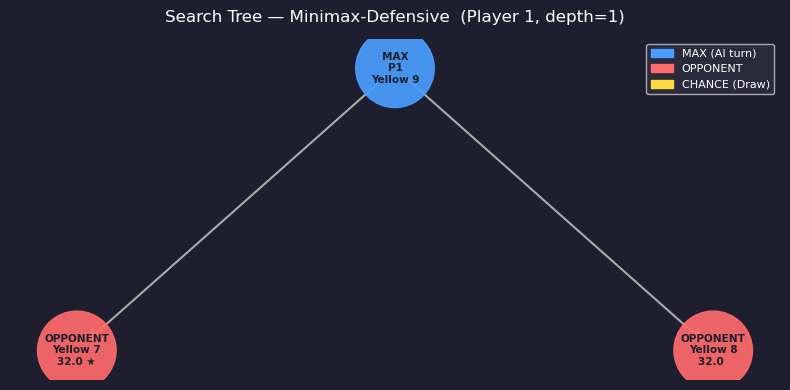

  → P1 plays  Yellow 8

───────────────────────────────────────────────────────
  Turn   2  │  Top card: Yellow 8
  Player 2's turn   │  Cards: P1=4  P2=5  P3=5
───────────────────────────────────────────────────────

  Player 2 (Expectimax)
  Top card : Yellow 8
  Hand     : [Red 7, Blue 4, Red 6, Green 5, Green Skip]
  AI decision (all moves at depth 1):
    Draw: DRAW                  Expected Score: 40.21 ◄ CHOSEN

┌─ SEARCH TREE  [Expectimax-Offensive]  Player 2
│  Root: Top card=Yellow 8  Hand=[Red 7, Blue 4, Red 6, Green 5, Green Skip]
│  Node type: MAX
│
│  └── [CHANCE] DRAW (Chance)
│          Score = 45.5  ★ BEST
└─ Best move: DRAW



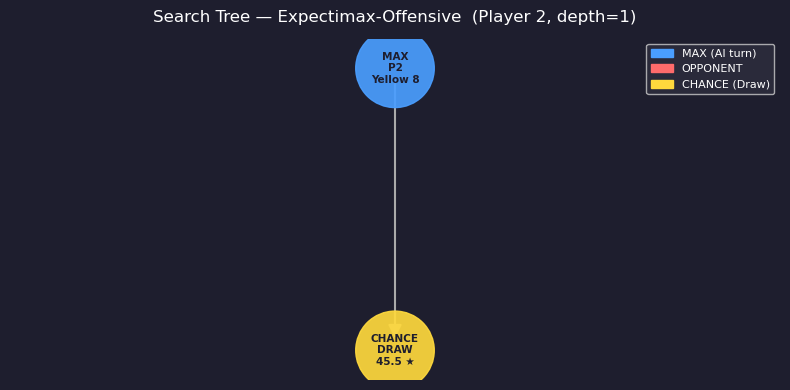

  → P2 draws a card

───────────────────────────────────────────────────────
  Turn   3  │  Top card: Yellow 8
  Player 3's turn   │  Cards: P1=4  P2=6  P3=5
───────────────────────────────────────────────────────

  Player 3 (Minimax)
  Top card : Yellow 8
  Hand     : [Red 1, Blue 3, Yellow 1, Red 2, Yellow 3]
  AI decision (all moves at depth 1):
    Play: Yellow 1              Score: 30.0 ◄ CHOSEN
    Play: Yellow 3              Score: 30.0

┌─ SEARCH TREE  [Minimax-Defensive]  Player 3
│  Root: Top card=Yellow 8  Hand=[Red 1, Blue 3, Yellow 1, Red 2, Yellow 3]
│  Node type: MAX
│
│  ├── [OPPONENT] Play Yellow 1
│  │       Score = 32.0  ★ BEST
│  └── [OPPONENT] Play Yellow 3
│          Score = 32.0
└─ Best move: Yellow 1



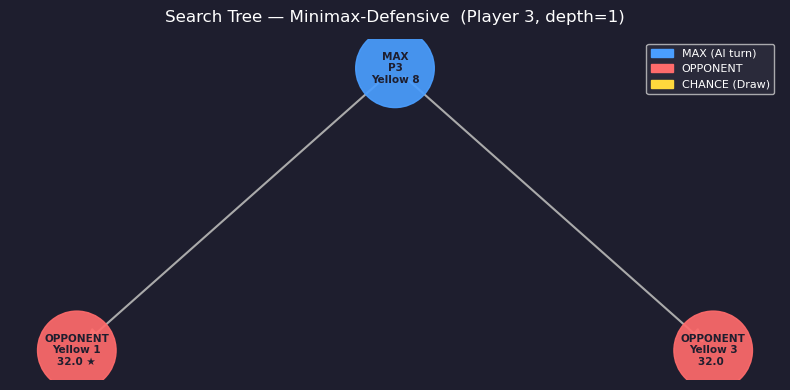

  → P3 plays  Yellow 1

═══════════════════════════════════════════════════════
  Game ended (max turns reached). Cards remaining:
    P1: 4 cards
    P2: 6 cards
    P3: 4 cards
═══════════════════════════════════════════════════════


In [30]:
random.seed(42)
final_state = play_game(mode='simulation', max_turns=3, show_trees=True)

## 11. Run — Full Simulation (No Tree Output, Runs to Completion)

In [31]:
random.seed(42)
final_state = play_game(mode='simulation', max_turns=200, show_trees=False)


═══════════════════════════════════════════════════════
 GAME AI - UNO using adversarial Search
  Mode: Simulation (3 AI players)
═══════════════════════════════════════════════════════
  Initial deal:
    P1: [Yellow 7, Blue 6, Red 8, Red 5, Yellow 8]
    P2: [Red 7, Blue 4, Red 6, Green 5, Green Skip]
    P3: [Red 1, Blue 3, Yellow 1, Red 2, Yellow 3]
  Top card: Yellow 9

───────────────────────────────────────────────────────
  Turn   1  │  Top card: Yellow 9
  Player 1's turn   │  Cards: P1=5  P2=5  P3=5
───────────────────────────────────────────────────────

  Player 1 (Minimax)
  Top card : Yellow 9
  Hand     : [Yellow 7, Blue 6, Red 8, Red 5, Yellow 8]
  AI decision (all moves at depth 1):
    Play: Yellow 7              Score: 30.0
    Play: Yellow 8              Score: 32.0 ◄ CHOSEN
  → P1 plays  Yellow 8

───────────────────────────────────────────────────────
  Turn   2  │  Top card: Yellow 8
  Player 2's turn   │  Cards: P1=4  P2=5  P3=5
────────────────────────────────

## 12. Run — Manual Mode (You Play as Player 3)

In [32]:
# random.seed(None)   # random seed for variety
# final_state = play_game(mode='manual', max_turns=200, show_trees=False, verbose=True)

## 13. Evaluation Function — Explanation & Weight Analysis

Variable,Defensive (P1/P3),Offensive (P2),Rationale
w_ai (own cards),7,4,Defensive AI penalises its own cards harder — minimising hand size is secondary to blocking
w_opp (opp cards),2,3,Offensive AI rewards opponent hand size more — wants opponents loaded with cards
w_skip (Skip cards),4,2,Defensive AI values Skip cards highly — controlling turn order is core to the defensive gameplan


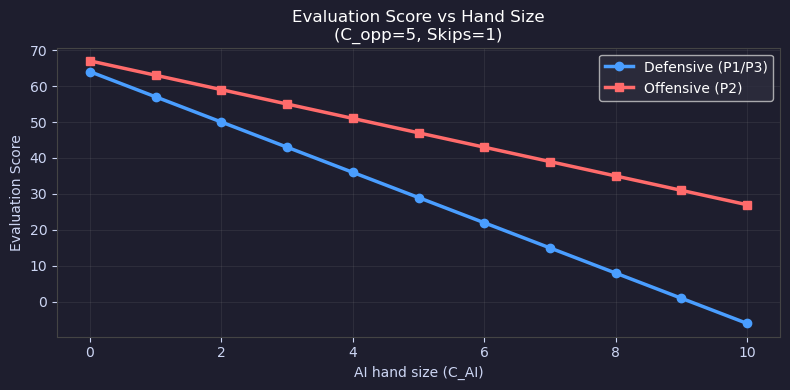

In [36]:
import numpy as np

display(HTML("""
<div style="background:#11111b; color:#cdd6f4; padding:24px; border-radius:10px; font-family:'JetBrains Mono', Consolas, monospace; line-height:1.4;">
    <h2 style="color:#89b4fa; margin-top:0; font-weight:600;">Evaluation Function</h2>
    <p style="color:#a6e3a1; font-size:1.1em; margin-bottom:20px;">Score = 50 − w_ai·C_AI + w_opp·C_opp + w_skip·S</p>
    
    <table style="width:100%; border-collapse:collapse; font-size:0.95em;">
        <tr style="background:#313244; border-bottom: 2px solid #11111b;">
            <th style="padding:16px; text-align:right;">Variable</th>
            <th style="padding:16px; text-align:center;">Defensive (P1/P3)</th>
            <th style="padding:16px; text-align:center;">Offensive (P2)</th>
            <th style="padding:16px; text-align:right; width:45%;">Rationale</th>
        </tr>
        <tr style="background:#1e1e2e; border-bottom: 2px solid #11111b;">
            <td style="padding:16px; text-align:right;">w_ai (own cards)</td>
            <td style="padding:16px; text-align:center;">7</td>
            <td style="padding:16px; text-align:center;">4</td>
            <td style="padding:16px; text-align:right;">Defensive AI penalises its own cards harder — minimising hand size is secondary to blocking</td>
        </tr>
        <tr style="background:#313244; border-bottom: 2px solid #11111b;">
            <td style="padding:16px; text-align:right;">w_opp (opp cards)</td>
            <td style="padding:16px; text-align:center;">2</td>
            <td style="padding:16px; text-align:center;">3</td>
            <td style="padding:16px; text-align:right;">Offensive AI rewards opponent hand size more — wants opponents loaded with cards</td>
        </tr>
        <tr style="background:#1e1e2e;">
            <td style="padding:16px; text-align:right;">w_skip (Skip cards)</td>
            <td style="padding:16px; text-align:center;">4</td>
            <td style="padding:16px; text-align:center;">2</td>
            <td style="padding:16px; text-align:right;">Defensive AI values Skip cards highly — controlling turn order is core to the defensive gameplan</td>
        </tr>
    </table>
</div>
"""))

# Visualise how score changes as hand size varies
hand_sizes = np.arange(0, 11)
opp_avg    = 5   # fixed for illustration
skips      = 1

defensive_scores = [50 - 7*h + 2*opp_avg + 4*skips for h in hand_sizes]
offensive_scores = [50 - 4*h + 3*opp_avg + 2*skips for h in hand_sizes]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

ax.plot(hand_sizes, defensive_scores, color='#4a9eff', linewidth=2.5,
        marker='o', label='Defensive (P1/P3)')
ax.plot(hand_sizes, offensive_scores, color='#ff6b6b', linewidth=2.5,
        marker='s', label='Offensive (P2)')

ax.set_xlabel('AI hand size (C_AI)', color='#cdd6f4')
ax.set_ylabel('Evaluation Score', color='#cdd6f4')
ax.set_title('Evaluation Score vs Hand Size\n(C_opp=5, Skips=1)',
             color='white', fontsize=12)
ax.tick_params(colors='#cdd6f4')
ax.spines[:].set_color('#444')
ax.legend(facecolor='#2e2e3e', labelcolor='white')
ax.grid(alpha=0.15, color='#888')
plt.tight_layout()
plt.show()

## 14. Standalone Tree Demo
Run this cell independently to see trees for a fresh game state without playing the full game.

  PLAYER 1 — Minimax Defensive Tree

┌─ SEARCH TREE  [Minimax-Defensive]  Player 1
│  Root: Top card=Yellow 5  Hand=[Blue 9, Red 3, Red 6, Green Skip, Red 5]
│  Node type: MAX
│
│  └── [OPPONENT] Play Red 5
│          Score = 36.0  ★ BEST
└─ Best move: Red 5



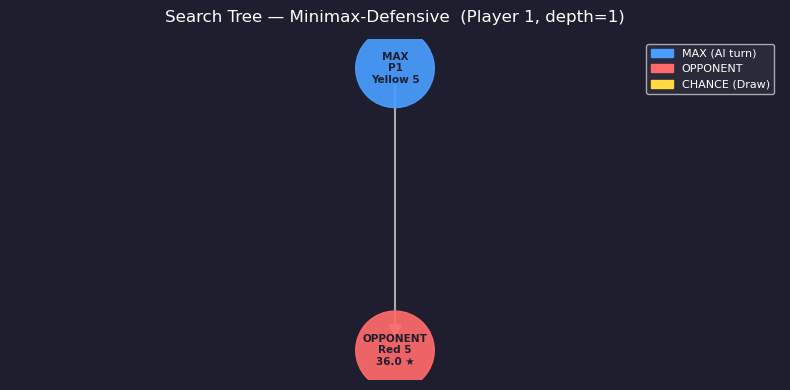


  Player 1 (Minimax)
  Top card : Yellow 5
  Hand     : [Blue 9, Red 3, Red 6, Green Skip, Red 5]
  AI decision (all moves at depth 1):
    Play: Red 5                 Score: 34.0 ◄ CHOSEN
  PLAYER 2 — Expectimax Offensive Tree

┌─ SEARCH TREE  [Expectimax-Offensive]  Player 2
│  Root: Top card=Red 5  Hand=[Red 9, Red 4, Green 1, Blue 2, Yellow 0]
│  Node type: MAX
│
│  ├── [OPPONENT] Play Red 9
│  │       Score = 47.5  ★ BEST
│  └── [OPPONENT] Play Red 4
│          Score = 47.5
└─ Best move: Red 9



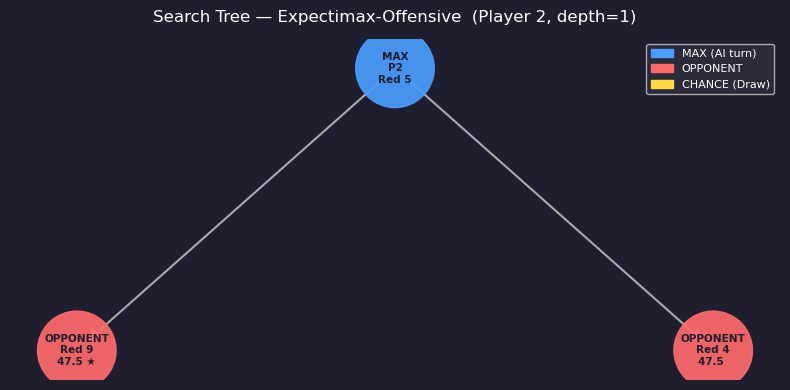

In [38]:
random.seed(7)
demo_state = initialise_game()

# Player 1 — Minimax tree
print("  PLAYER 1 — Minimax Defensive Tree")
print_search_tree(demo_state, player_idx=0, algorithm='minimax')
draw_search_tree(demo_state,  player_idx=0, algorithm='minimax')

# Advance to P2's turn
p1_move, _ = minimax_decision(demo_state, player_idx=0, depth=3)
demo_state  = apply_move(demo_state, p1_move)

# Player 2 — Expectimax tree
print("  PLAYER 2 — Expectimax Offensive Tree")
print_search_tree(demo_state, player_idx=1, algorithm='expectimax')
draw_search_tree(demo_state,  player_idx=1, algorithm='expectimax')